# Schelling's Model of Segregation

Homework 1 - Particle Methods, Spring 2026;
Ferdinando Giordano.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.dpi': 120,
})

### System Initialization & Environment Setup

In this section, we construct the initial state of our spatial segregation model. We treat the agents as particles on a 2D lattice, applying specific population densities and topological rules to simulate an infinite environment.

**Key Model Parameters:** <br>
**Grid Dimensions:** A $100 \times 100$ matrix. <br>
**Population Distribution:** Agents and empty spaces are distributed randomly across the grid with the following exact ratios:
**Red Agents:** 45% <br>
**Blue Agents:** 45% <br>
**Empty Cells:** 10% <br>
**Boundary Conditions:** The grid will utilize periodic boundaries in both the horizontal and vertical directions. <br>

In [2]:
N = 100
EMPTY, RED, BLUE = 0, 1, 2

CMAP = mcolors.ListedColormap(['white', '#d62728', '#1f77b4'])
NORM = mcolors.BoundaryNorm([-.5, .5, 1.5, 2.5], CMAP.N)

OFFSETS = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

In [3]:
def init_grid(seed=None):
    rng  = np.random.default_rng(seed)
    n    = N * N
    nr, nb = int(0.45*n), int(0.45*n)
    flat = np.array([RED]*nr + [BLUE]*nb + [EMPTY]*(n-nr-nb), dtype=np.int8)
    rng.shuffle(flat)
    return flat.reshape(N, N)

def show_grid(ax, grid, title='', converged=True):
    ax.imshow(grid, cmap=CMAP, norm=NORM, interpolation='nearest')
    ax.set_title(title, color='black' if converged else '#d62728')
    ax.axis('off')

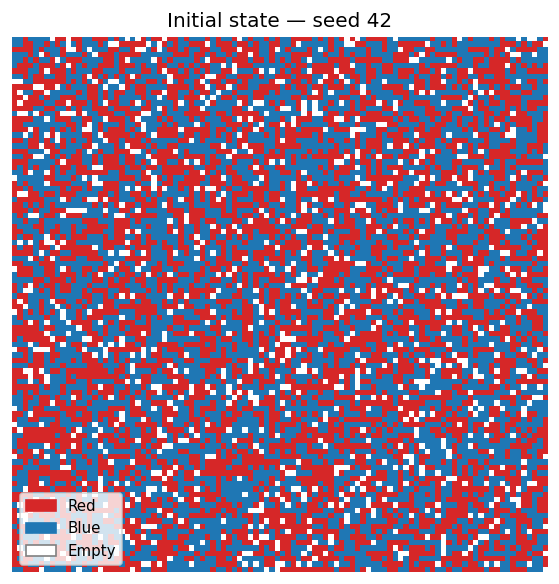

In [15]:
g0 = init_grid(seed=42)

fig, ax = plt.subplots(figsize=(5, 5))
show_grid(ax, g0, 'Initial state — seed 42')
ax.legend(handles=[
    Patch(color='#d62728', label='Red'),
    Patch(color='#1f77b4', label='Blue'),
    Patch(facecolor='white', edgecolor='gray', label='Empty'),
], loc='lower left', fontsize=9)
plt.tight_layout()
fig.savefig('figures/initial_state.pdf', bbox_inches='tight')
plt.show()

In [5]:
def happy_map(grid, H):
    # vectorized: count same-type neighbours via np.roll (periodic BC)
    same = np.zeros_like(grid, dtype=np.int8)
    for dr, dc in OFFSETS:
        nbr = np.roll(np.roll(grid, -dr, axis=0), -dc, axis=1)
        same += ((nbr == grid) & (grid != EMPTY)).astype(np.int8)
    return (grid == EMPTY) | (same >= H)

def is_happy(grid, r, c, H):
    if grid[r, c] == EMPTY:
        return True
    same = sum(grid[(r+dr)%N, (c+dc)%N] == grid[r, c] for dr, dc in OFFSETS)
    return same >= H

def frac_happy(grid, H):
    hmap = happy_map(grid, H)
    return float(hmap[grid != EMPTY].mean())

In [6]:
def move_horizontal(grid, r, c, rng):
    step = int(rng.integers(0, 2)) * 2 - 1  # -1 (left) or +1 (right)
    for k in range(1, N):
        nc = (c + k*step) % N
        if grid[r, nc] == EMPTY:
            return (r, nc)
    return None

def move_random_dir(grid, r, c, rng):
    d = int(rng.integers(0, 4))  # 0=up 1=down 2=left 3=right
    if   d == 0: seq = [((r-k)%N, c)        for k in range(1, N)]
    elif d == 1: seq = [((r+k)%N, c)        for k in range(1, N)]
    elif d == 2: seq = [(r,        (c-k)%N) for k in range(1, N)]
    else:        seq = [(r,        (c+k)%N) for k in range(1, N)]
    for nr, nc in seq:
        if grid[nr, nc] == EMPTY:
            return (nr, nc)
    return None

In [7]:
def run_iter(grid, H, order, movement, rng):
    rows, cols = np.where(grid != EMPTY)
    pos = list(zip(rows.tolist(), cols.tolist()))
    if order == 'random':
        rng.shuffle(pos)
    move = move_horizontal if movement == 'horizontal' else move_random_dir
    for r, c in pos:
        if not is_happy(grid, r, c, H):
            t = move(grid, r, c, rng)
            if t:
                grid[t] = grid[r, c]
                grid[r, c] = EMPTY

def run_sim(g0, H, order, movement, max_iter=500, seed=None):
    grid = g0.copy()
    rng  = np.random.default_rng(seed)
    hist = []
    for _ in range(max_iter):
        run_iter(grid, H, order, movement, rng)
        f = frac_happy(grid, H)
        hist.append(f)
        if f >= 1.0:
            return grid, len(hist), hist
    return grid, None, hist

### a. System Dynamics & Strategy Testing (H = 4)

In this section, we implement the core simulation loop to observe the system's progression toward a stable state. We set the happiness threshold to $H = 4$. During each global iteration, the system evaluates the state of every agent. Unhappy agents are displaced to the nearest empty cell.

To fulfill Part (a) of the assignment, this code is structured to allow toggling between different computational strategies:
* **Update Order:** Comparing sequential (row-by-row) updates versus a randomized update sequence.
* **Displacement Rule:** Comparing purely horizontal movement versus omnidirectional movement to the nearest vacancy.

We will track the total number of iterations required to reach a global "happy" state (equilibrium) to evaluate which strategy is the most physically realistic and efficient.

In [8]:
H = 4
SEEDS = [42, 123, 777]

COMBOS = [
    ('row',    'horizontal', 'RO-H',  'Row + Horizontal'),
    ('row',    'random_dir', 'RO-RD', 'Row + Random dir'),
    ('random', 'horizontal', 'RS-H',  'Random + Horizontal'),
    ('random', 'random_dir', 'RS-RD', 'Random + Random dir'),
]

res = {}
for order, movement, key, label in COMBOS:
    res[key] = []
    for s in SEEDS:
        gf, ni, hist = run_sim(init_grid(s), H, order, movement, seed=s+1000)
        res[key].append({'seed': s, 'ni': ni, 'gf': gf, 'hist': hist})
    iters = [r['ni'] if r['ni'] else '>500' for r in res[key]]
    print(f'{label:30s}: {iters}')

Row + Horizontal              : ['>500', '>500', '>500']
Row + Random dir              : [115, 166, 100]
Random + Horizontal           : ['>500', '>500', '>500']
Random + Random dir           : [59, 75, 81]


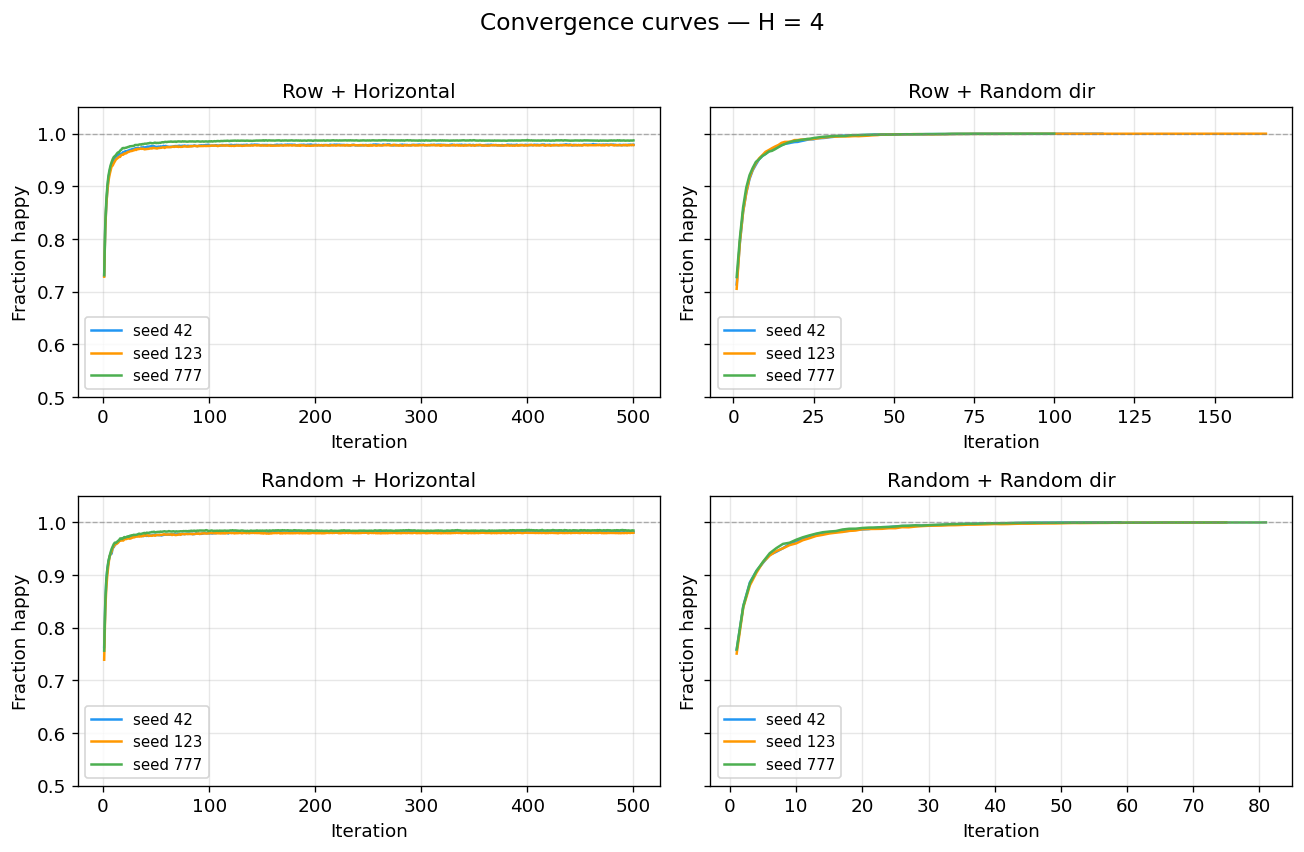

In [16]:
CLRS = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
for ax, (_, _, key, label) in zip(axes.flat, COMBOS):
    for run, col in zip(res[key], CLRS):
        ax.plot(range(1, len(run['hist'])+1), run['hist'],
                color=col, label=f"seed {run['seed']}")
    ax.set_title(label)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Fraction happy')
    ax.set_ylim(0.5, 1.05)
    ax.axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.6)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f'Convergence curves — H = {H}', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig('figures/convergence_curves.pdf', bbox_inches='tight')
plt.show()

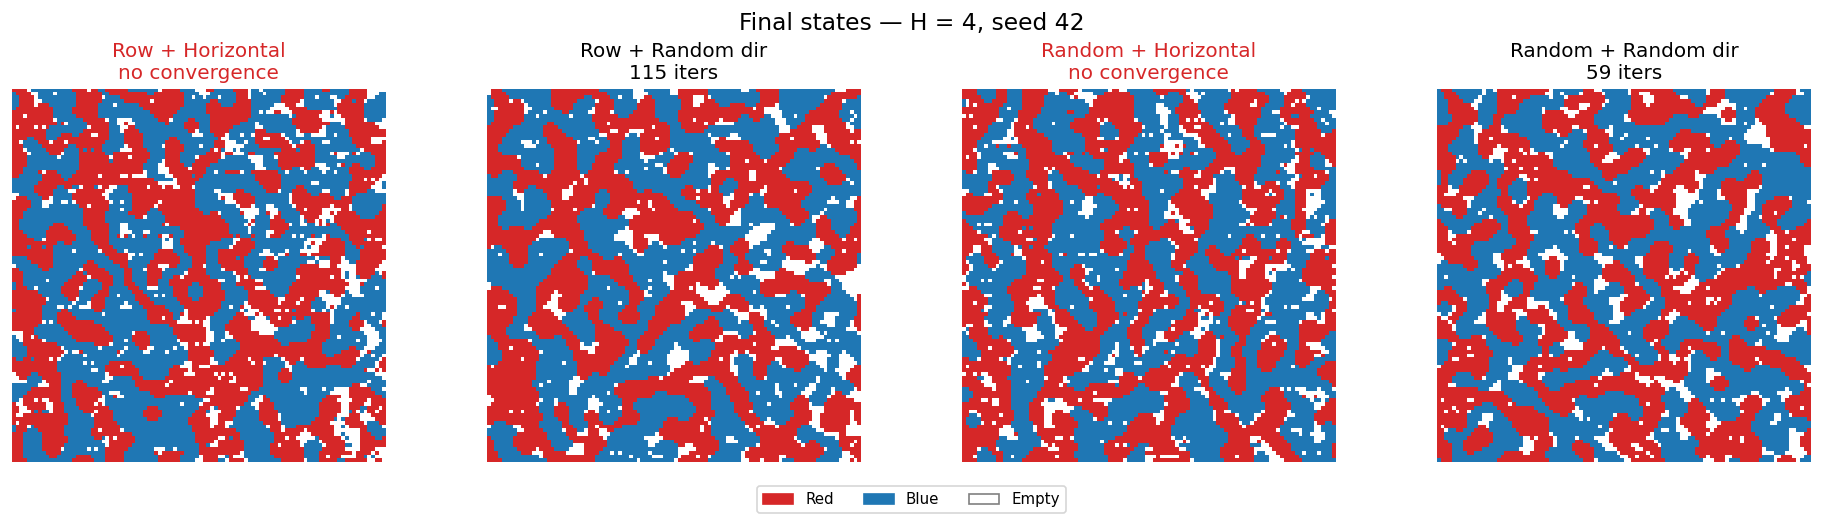

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, _, key, label) in zip(axes, COMBOS):
    run  = res[key][0]
    conv = run['ni'] is not None
    ni   = run['ni']
    ni_s = f'{ni} iters' if conv else 'no convergence'
    show_grid(ax, run['gf'], f'{label}\n{ni_s}', converged=conv)

fig.legend(handles=[
    Patch(color='#d62728', label='Red'),
    Patch(color='#1f77b4', label='Blue'),
    Patch(facecolor='white', edgecolor='gray', label='Empty'),
], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.suptitle(f'Final states — H = {H}, seed {SEEDS[0]}', fontsize=14)
plt.tight_layout()
fig.savefig('figures/final_states_a.pdf', bbox_inches='tight')
plt.show()

### Results — Part a

| Strategy | Seed 42 | Seed 123 | Seed 777 |
|----------|---------|----------|----------|
| Row + Horizontal    | >500 | >500 | >500 |
| Row + Random dir    | 115  | 166  | 100  |
| Random + Horizontal | >500 | >500 | >500 |
| Random + Random dir | 59   | 75   | 81   |

**Best strategy: Random order + Random direction** (~59–81 iterations, no artifacts).

Horizontal-only movement causes persistent oscillations: agents cycle left/right without resolving vertical neighbourhood mismatches, so the system never reaches full happiness.

### b. Parameter Sweep and Phase Transitions (Varying H)

In this final section, we lock in the optimal update and movement strategy identified in Part (a). We then perform a parameter sweep of the happiness threshold, varying H from 1 to 8. 

The goal is to observe **phase transitions** in the system's behavior. In the context of Particle Methods and Schelling's model, we are looking for the critical points where the system shifts from a highly mixed steady state, to macroscopic clustering (segregation), and finally to a "frustrated" state where equilibrium can no longer be reached.

For each value of H, we will re-initialize the grid to a random state, run the simulation until all agents are happy (or until a maximum iteration limit is reached), and visualize the final spatial distribution.

In [11]:
H_VALS = list(range(1, 9))

res_b = {}
for Hv in H_VALS:
    res_b[Hv] = []
    for s in SEEDS:
        gf, ni, hist = run_sim(init_grid(s), Hv, 'random', 'random_dir',
                               max_iter=1000, seed=s+2000)
        res_b[Hv].append({'seed': s, 'ni': ni, 'gf': gf, 'hist': hist})
    iters = [r['ni'] if r['ni'] else '>1000' for r in res_b[Hv]]
    print(f'H = {Hv}: {iters}')

H = 1: [5, 2, 2]
H = 2: [12, 8, 13]
H = 3: [36, 38, 44]
H = 4: [105, 89, 80]
H = 5: ['>1000', '>1000', '>1000']
H = 6: ['>1000', '>1000', '>1000']
H = 7: ['>1000', '>1000', '>1000']
H = 8: ['>1000', '>1000', '>1000']


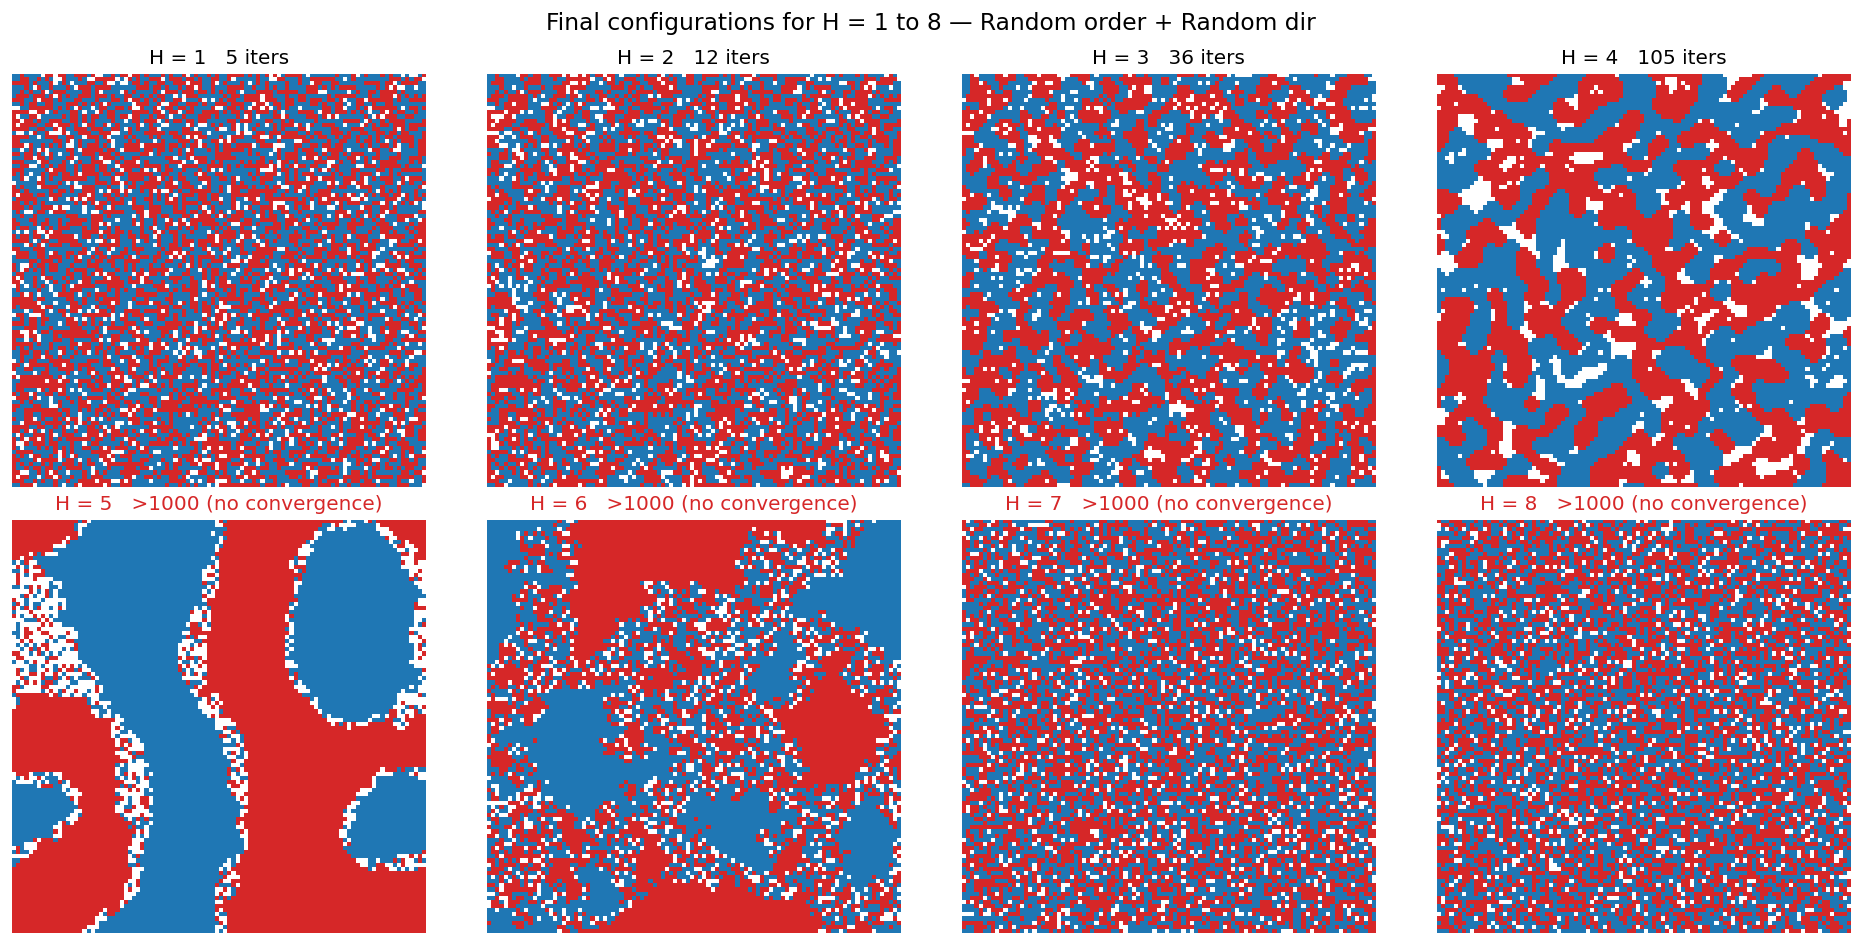

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, Hv in zip(axes.flat, H_VALS):
    run  = res_b[Hv][0]
    conv = run['ni'] is not None
    ni   = run['ni']
    ni_s = f'{ni} iters' if conv else '>1000 (no convergence)'
    show_grid(ax, run['gf'], f'H = {Hv}   {ni_s}', converged=conv)

plt.suptitle('Final configurations for H = 1 to 8 — Random order + Random dir',
             fontsize=14)
plt.tight_layout()
fig.savefig('figures/final_states_h.pdf', bbox_inches='tight')
plt.show()

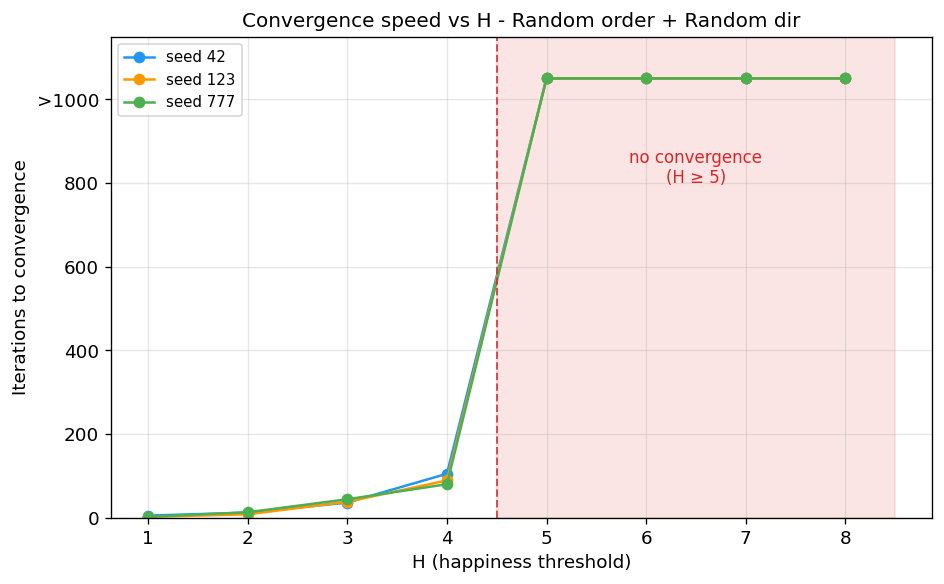

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, s in enumerate(SEEDS):
    iters = [res_b[Hv][i]['ni'] if res_b[Hv][i]['ni'] else 1050 for Hv in H_VALS]
    ax.plot(H_VALS, iters, marker='o', color=CLRS[i], label=f'seed {s}')

ax.axvspan(4.5, 8.5, alpha=0.12, color='#d62728')
ax.axvline(4.5, color='#d62728', lw=1.2, ls='--', alpha=0.8)
ax.text(6.5, 800, 'no convergence\n(H ≥ 5)', color='#d62728', fontsize=10, ha='center')

ax.set_xlabel('H (happiness threshold)')
ax.set_ylabel('Iterations to convergence')
ax.set_title('Convergence speed vs H - Random order + Random dir')
ax.set_xticks(H_VALS)
ax.set_ylim(0, 1150)
ax.set_yticks([0, 200, 400, 600, 800, 1000])
ax.set_yticklabels(['0', '200', '400', '600', '800', '>1000'])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('figures/iterations_vs_h.pdf', bbox_inches='tight')
plt.show()

### Results - Part b

| H | Seed 42 | Seed 123 | Seed 777 | Observation |
|---|---------|----------|----------|-------------|
| 1 | 5   | 2   | 2   | Converges almost instantly; minimal segregation |
| 2 | 12  | 8   | 13  | Fast; loose clusters |
| 3 | 36  | 38  | 44  | Moderate clusters |
| 4 | 105 | 89  | 80  | Strong segregation; ~100 iterations |
| 5 | >1000 | >1000 | >1000 | **No convergence** — phase transition |
| 6–8 | >1000 | >1000 | >1000 | No convergence |

**Phase transition at H = 4 → 5.** With 45% Red, 45% Blue and only 10% empty cells, an agent with H = 5 needs 5 same-type neighbours out of 8 — geometrically impossible for most boundary agents. The system enters a non-equilibrium state and never reaches full happiness.

For H ≤ 4 the model always converges, producing increasingly tight clusters as H grows.